<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [73]:
#Importation de la librairie Pandas
import pandas as pd

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [74]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [75]:
#Importation du fichier population.csv
population = pd.read_csv('/content/drive/MyDrive/Projet_4_data/population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('/content/drive/MyDrive/Projet_4_data/dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('/content/drive/MyDrive/Projet_4_data/aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('/content/drive/MyDrive/Projet_4_data/sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [76]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [77]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes est :", population.shape[1])
#La nature des données dans chacune des colonnes
print(population.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print(population.count())

Le nombre de colonnes est : 3
Zone       object
Année       int64
Valeur    float64
dtype: object
Zone      1416
Année     1416
Valeur    1416
dtype: int64


In [78]:
#Affichage les 5 premières lignes de la table
print(population.head(5))

          Zone  Année     Valeur
0  Afghanistan   2013  32269.589
1  Afghanistan   2014  33370.794
2  Afghanistan   2015  34413.603
3  Afghanistan   2016  35383.032
4  Afghanistan   2017  36296.113


In [79]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur'] = population['Valeur']*1000

In [80]:
#changement du nom de la colonne Valeur par Population
population = population.rename(columns={'Valeur':'Population'})
print(population.columns)

Index(['Zone', 'Année', 'Population'], dtype='object')


In [81]:
#Affichage les 5 premières lignes de la table pour voir les modifications
print(population.head(5))

          Zone  Année  Population
0  Afghanistan   2013  32269589.0
1  Afghanistan   2014  33370794.0
2  Afghanistan   2015  34413603.0
3  Afghanistan   2016  35383032.0
4  Afghanistan   2017  36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [82]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [83]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes est :",dispo_alimentaire.shape[1])

Le nombre de colonnes est : 18


In [84]:
#Affichage les 5 premières lignes de la table
print(dispo_alimentaire.head(5))

          Zone                Produit   Origine  Aliments pour animaux  \
0  Afghanistan       Abats Comestible   animale                    NaN   
1  Afghanistan        Agrumes, Autres  vegetale                    NaN   
2  Afghanistan  Aliments pour enfants  vegetale                    NaN   
3  Afghanistan                 Ananas  vegetale                    NaN   
4  Afghanistan                Bananes  vegetale                    NaN   

   Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
0                  NaN                                             5.0   
1                  NaN                                             1.0   
2                  NaN                                             1.0   
3                  NaN                                             0.0   
4                  NaN                                             4.0   

   Disponibilité alimentaire en quantité (kg/personne/an)  \
0                                               1

In [85]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)

In [86]:
#multiplication de toutes les lignes contenant des milliers de tonne en KG
donnees_a_convertir = ['Aliments pour animaux','Disponibilité intérieure','Exportations - Quantité','Importations - Quantité','Nourriture','Pertes','Production','Semences','Traitement','Autres Utilisations']
dispo_alimentaire[donnees_a_convertir] = dispo_alimentaire[donnees_a_convertir]*1000

In [87]:
#Affichage les 5 premières lignes de la table
print(dispo_alimentaire.head(5))

          Zone                Produit   Origine  Aliments pour animaux  \
0  Afghanistan       Abats Comestible   animale                    0.0   
1  Afghanistan        Agrumes, Autres  vegetale                    0.0   
2  Afghanistan  Aliments pour enfants  vegetale                    0.0   
3  Afghanistan                 Ananas  vegetale                    0.0   
4  Afghanistan                Bananes  vegetale                    0.0   

   Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
0                  0.0                                             5.0   
1                  0.0                                             1.0   
2                  0.0                                             1.0   
3                  0.0                                             0.0   
4                  0.0                                             4.0   

   Disponibilité alimentaire en quantité (kg/personne/an)  \
0                                               1

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [88]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [89]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes est :",aide_alimentaire.shape[1])


Le nombre de colonnes est : 4


In [90]:
#Affichage les 5 premières lignes de la table
print(aide_alimentaire.head(5))

  Pays bénéficiaire  Année              Produit  Valeur
0       Afghanistan   2013  Autres non-céréales     682
1       Afghanistan   2014  Autres non-céréales     335
2       Afghanistan   2013         Blé et Farin   39224
3       Afghanistan   2014         Blé et Farin   15160
4       Afghanistan   2013             Céréales   40504


In [91]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire = aide_alimentaire.rename(columns={'Pays bénéficiaire':'Zone'})
print(aide_alimentaire.columns)

Index(['Zone', 'Année', 'Produit', 'Valeur'], dtype='object')


In [92]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur']=aide_alimentaire['Valeur']*1000

In [93]:
#Affichage les 5 premières lignes de la table
print(aide_alimentaire.head(5))

          Zone  Année              Produit    Valeur
0  Afghanistan   2013  Autres non-céréales    682000
1  Afghanistan   2014  Autres non-céréales    335000
2  Afghanistan   2013         Blé et Farin  39224000
3  Afghanistan   2014         Blé et Farin  15160000
4  Afghanistan   2013             Céréales  40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [94]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [95]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes est :",sous_nutrition.shape[1])

Le nombre de colonnes est : 3


In [96]:
#Afficher les 5 premières lignes de la table
print(sous_nutrition.head(5))

          Zone      Année Valeur
0  Afghanistan  2012-2014    8.6
1  Afghanistan  2013-2015    8.8
2  Afghanistan  2014-2016    8.9
3  Afghanistan  2015-2017    9.7
4  Afghanistan  2016-2018   10.5


In [145]:
#Conversion de la colonne sous nutrition en numérique
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])

KeyError: 'Valeur'

Echec de la conversion, car présence de données noté "NaN" qui ne peuvent donc être converties

In [98]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce').fillna(0)
print(sous_nutrition.head(5))

          Zone      Année  Valeur
0  Afghanistan  2012-2014     8.6
1  Afghanistan  2013-2015     8.8
2  Afghanistan  2014-2016     8.9
3  Afghanistan  2015-2017     9.7
4  Afghanistan  2016-2018    10.5


In [99]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition = sous_nutrition.rename(columns={'Valeur':'sous_nutrition'})
print(sous_nutrition.columns)

Index(['Zone', 'Année', 'sous_nutrition'], dtype='object')


In [100]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['sous_nutrition']=sous_nutrition['sous_nutrition']*1000000

In [101]:
#Afficher les 5 premières lignes de la table
print(sous_nutrition.head(5))

          Zone      Année  sous_nutrition
0  Afghanistan  2012-2014       8600000.0
1  Afghanistan  2013-2015       8800000.0
2  Afghanistan  2014-2016       8900000.0
3  Afghanistan  2015-2017       9700000.0
4  Afghanistan  2016-2018      10500000.0


**Conclusion des analyses exploratrices**


*  Les données sont importées correctement et correspondent aux fichiers CSV
*   J'ai pu renommer le titre de certaine colonne
* Unification des unités
* Modification des NaN par l'unité 0

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [102]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
  # extraire les années de sous-nutrition
sous_nutrition[['debut','fin']]=sous_nutrition['Année'].str.split('-',expand=True).astype(int)
  # calculer l'année intermédiaire
sous_nutrition['annee_intermediaire']=((sous_nutrition['debut']+sous_nutrition['fin'])/2).astype(int)

  # Filtrage de l'année 2017
population_2017 = population[population['Année'] == 2017]
sous_nutrition_2017 = sous_nutrition[sous_nutrition['annee_intermediaire'] == 2017]

annee_2017 = pd.merge(population_2017, sous_nutrition_2017, on='Zone', how='left')


In [103]:
#Affichage du dataset
print(annee_2017)

                                       Zone  Année_x  Population    Année_y  \
0                               Afghanistan     2017  36296113.0  2016-2018   
1                            Afrique du Sud     2017  57009756.0  2016-2018   
2                                   Albanie     2017   2884169.0  2016-2018   
3                                   Algérie     2017  41389189.0  2016-2018   
4                                 Allemagne     2017  82658409.0  2016-2018   
..                                      ...      ...         ...        ...   
231  Venezuela (République bolivarienne du)     2017  29402484.0  2016-2018   
232                                Viet Nam     2017  94600648.0  2016-2018   
233                                   Yémen     2017  27834819.0  2016-2018   
234                                  Zambie     2017  16853599.0  2016-2018   
235                                Zimbabwe     2017  14236595.0  2016-2018   

     sous_nutrition   debut     fin  annee_intermed

In [104]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
  # taux_sous_nutrition = (sous_nutrition / population ) * 100

taux_sous_nutrition = (annee_2017['sous_nutrition'] / annee_2017['Population']) * 100
annee_2017['taux_sous_nutrition'] = taux_sous_nutrition.round(2)
print(annee_2017[['Zone','taux_sous_nutrition']])

                                       Zone  taux_sous_nutrition
0                               Afghanistan                28.93
1                            Afrique du Sud                 5.44
2                                   Albanie                 3.47
3                                   Algérie                 3.14
4                                 Allemagne                 0.00
..                                      ...                  ...
231  Venezuela (République bolivarienne du)                27.21
232                                Viet Nam                 6.87
233                                   Yémen                 0.00
234                                  Zambie                 0.00
235                                Zimbabwe                 0.00

[236 rows x 2 columns]


In [105]:
#Calcul et affichage du nombre de personnes en état de sous nutrition total (rajout)
total_sous_nutrition = annee_2017['sous_nutrition'].sum()
total_population = annee_2017['Population'].sum()
taux_sous_nutrition_total = (total_sous_nutrition / total_population) * 100
print("En 2017, la population est de :", total_population)
print ("En 2017, il y a :", total_sous_nutrition, "Million de personne sous-nourris")
print("Le taux de sous-nutrition en 2017 est de :", taux_sous_nutrition_total.round(2), "%")

En 2017, la population est de : 7548134111.0
En 2017, il y a : 535700000.0 Million de personne sous-nourris
Le taux de sous-nutrition en 2017 est de : 7.1 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

Combien mange en moyenne un être humain ? Source => https://www.santepubliquefrance.fr/determinants-de-sante/nutrition-et-activite-physique/articles/enns-etude-nationale-nutrition-sante/alimentation-apports-en-energie-et-nutriments-adultes-tableaux-de-distribution-enns

Selon santé publique france en moyenne un homme consomme 2264 kcal/j et une femme 1664 kcal par jour. Soit une moyenne pour la population de **1964 kCal/j**

In [107]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population, en groupant par la Zone
tri_dispo = dispo_alimentaire.groupby(['Zone'])[['Produit','Origine','Aliments pour animaux',
       'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité intérieure', 'Exportations - Quantité',
       'Importations - Quantité', 'Nourriture', 'Pertes', 'Production',
       'Semences', 'Traitement', 'Variation de stock']].sum(numeric_only=True).reset_index()
population_2017 = population[population['Année'] == 2017]
dispo_zone_2017 = pd.merge((population_2017), (tri_dispo), on='Zone', how='left')

In [108]:
#Affichage du nouveau dataframe
print(dispo_zone_2017)

                                       Zone  Année  Population  \
0                               Afghanistan   2017  36296113.0   
1                            Afrique du Sud   2017  57009756.0   
2                                   Albanie   2017   2884169.0   
3                                   Algérie   2017  41389189.0   
4                                 Allemagne   2017  82658409.0   
..                                      ...    ...         ...   
231  Venezuela (République bolivarienne du)   2017  29402484.0   
232                                Viet Nam   2017  94600648.0   
233                                   Yémen   2017  27834819.0   
234                                  Zambie   2017  16853599.0   
235                                Zimbabwe   2017  14236595.0   

     Aliments pour animaux  Autres Utilisations  \
0                 768000.0             415000.0   
1                5309000.0             876000.0   
2                 660000.0             174000.0   
3  

In [109]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
dispo_zone_2017['dispo_kcal'] = dispo_zone_2017['Disponibilité alimentaire (Kcal/personne/jour)'] * dispo_zone_2017['Population']
print(dispo_zone_2017)

                                       Zone  Année  Population  \
0                               Afghanistan   2017  36296113.0   
1                            Afrique du Sud   2017  57009756.0   
2                                   Albanie   2017   2884169.0   
3                                   Algérie   2017  41389189.0   
4                                 Allemagne   2017  82658409.0   
..                                      ...    ...         ...   
231  Venezuela (République bolivarienne du)   2017  29402484.0   
232                                Viet Nam   2017  94600648.0   
233                                   Yémen   2017  27834819.0   
234                                  Zambie   2017  16853599.0   
235                                Zimbabwe   2017  14236595.0   

     Aliments pour animaux  Autres Utilisations  \
0                 768000.0             415000.0   
1                5309000.0             876000.0   
2                 660000.0             174000.0   
3  

In [110]:
#Calcul du nombre d'humains pouvant être nourris
total_dispo_kcal_2017 = dispo_zone_2017['dispo_kcal'].sum()
nb_humains_nourris = total_dispo_kcal_2017 / 1964
total_population_2017 = dispo_zone_2017['Population'].sum()
print("Le nombre d'humain pouvant être nourris en 2017 est de :", nb_humains_nourris.round(2)/1000000000, "Milliards")
print("Pour une population total en 2017 de :", total_population_2017/1000000000 , "Milliards")

Le nombre d'humain pouvant être nourris en 2017 est de : 10.651214168700001 Milliards
Pour une population total en 2017 de : 7.548134111 Milliards


In [111]:
#Dispo Kcal de la Thailande en 2017
dispo_thailande = dispo_zone_2017[dispo_zone_2017['Zone'] == 'Thaïlande']['Disponibilité alimentaire (Kcal/personne/jour)']
print(dispo_thailande)


218    2785.0
Name: Disponibilité alimentaire (Kcal/personne/jour), dtype: float64


La Thaïlande a donc une disponibilité en Calorie suffisante pour nourrire sa population

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [112]:
#Transfert des données avec les végétaux dans un nouveau dataframe, en groupant par Zone
dispo_vegetale = dispo_alimentaire[dispo_alimentaire['Origine']=='vegetale'].groupby(['Zone'])[['Produit','Origine','Aliments pour animaux',
       'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité intérieure', 'Exportations - Quantité',
       'Importations - Quantité', 'Nourriture', 'Pertes', 'Production',
       'Semences', 'Traitement', 'Variation de stock']].sum(numeric_only=True).reset_index()
dispo_zone_vegetal = pd.merge((population_2017), (dispo_vegetale), on='Zone', how='left')
dispo_zone_vegetal['dispo_kcal_vegetale'] = dispo_zone_vegetal['Disponibilité alimentaire (Kcal/personne/jour)'] * dispo_zone_vegetal['Population']

print(dispo_zone_vegetal)

                                       Zone  Année  Population  \
0                               Afghanistan   2017  36296113.0   
1                            Afrique du Sud   2017  57009756.0   
2                                   Albanie   2017   2884169.0   
3                                   Algérie   2017  41389189.0   
4                                 Allemagne   2017  82658409.0   
..                                      ...    ...         ...   
231  Venezuela (République bolivarienne du)   2017  29402484.0   
232                                Viet Nam   2017  94600648.0   
233                                   Yémen   2017  27834819.0   
234                                  Zambie   2017  16853599.0   
235                                Zimbabwe   2017  14236595.0   

     Aliments pour animaux  Autres Utilisations  \
0                 645000.0             415000.0   
1                5122000.0             761000.0   
2                 559000.0             172000.0   
3  

In [113]:
#Calcul du nombre de kcal disponible pour les végétaux
total_dispo_vegetale = dispo_zone_vegetal['dispo_kcal_vegetale'].sum()

In [114]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
nb_humains_nourris_vegetal = total_dispo_vegetale / 1964
print("Le nombre d'humain pouvant être nourris avec les végétaux en 2017 est de :", nb_humains_nourris_vegetal.round(2)/1000000000, "Milliards")

Le nombre d'humain pouvant être nourris avec les végétaux en 2017 est de : 8.78857648243 Milliards


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

La disponibilité intérieur se calcule par l'équation

Disponibilité intérieur = Semences + Pertes + Nourritures + Aliments pour animaux + Traitements + Autres utilisation

Ici notre fichier de donnée nous donne directement les valeurs

In [115]:
#Calcul de la disponibilité totale
Disponibilite_interieure = dispo_zone_2017['Disponibilité intérieure'].sum()
print(Disponibilite_interieure)


9733927000.0


In [116]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures,
categorie=dispo_zone_2017[['Aliments pour animaux','Autres Utilisations','Nourriture','Pertes','Traitement','Semences']]
for i in categorie:
  total = categorie[i].sum()*100/Disponibilite_interieure
  print(f"{i} : {total:.2f}%")


Aliments pour animaux : 13.23%
Autres Utilisations : 8.82%
Nourriture : 49.37%
Pertes : 4.65%
Traitement : 22.45%
Semences : 1.58%


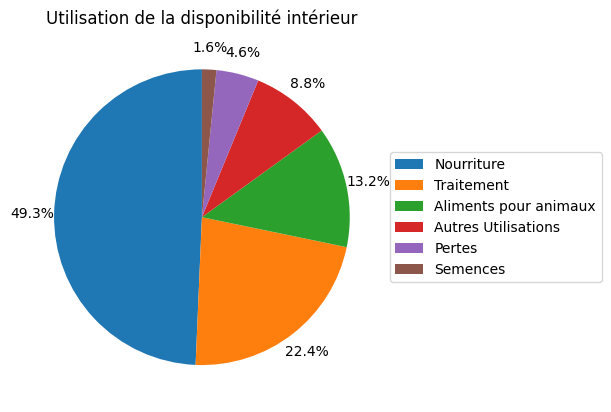

In [117]:
#Graphique pour illustrer cette disponibilité intérieur
import matplotlib.pyplot as plt
utilisation_dispo= (dispo_zone_2017[['Aliments pour animaux','Autres Utilisations','Nourriture','Pertes','Traitement','Semences']].sum().sort_values(ascending=False))
plt.pie(utilisation_dispo.values, autopct = '%.1f%%', pctdistance= 1.15, startangle=90)
plt.title ('Utilisation de la disponibilité intérieur')
plt.legend(utilisation_dispo.index, loc = 7, bbox_to_anchor = (1.60, 0.5))
plt.show()



<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [118]:
#Affichage de l'ensemble des produits de la table dispo_alimentaire
print(dispo_alimentaire['Produit'].unique().tolist())

['Abats Comestible', 'Agrumes, Autres', 'Aliments pour enfants', 'Ananas', 'Bananes', 'Beurre, Ghee', 'Bière', 'Blé', 'Boissons Alcooliques', 'Café', 'Coco (Incl Coprah)', 'Crème', 'Céréales, Autres', 'Dattes', 'Edulcorants Autres', 'Feve de Cacao', 'Fruits, Autres', 'Graines de coton', 'Graines de tournesol', 'Graisses Animales Crue', 'Huil Plantes Oleif Autr', 'Huile Graines de Coton', "Huile d'Arachide", "Huile d'Olive", 'Huile de Colza&Moutarde', 'Huile de Palme', 'Huile de Soja', 'Huile de Sésame', 'Huile de Tournesol', 'Lait - Excl Beurre', 'Légumes, Autres', 'Légumineuses Autres', 'Maïs', 'Miel', 'Millet', 'Miscellanees', 'Noix', 'Oeufs', 'Olives', 'Oranges, Mandarines', 'Orge', 'Plantes Oleiferes, Autre', 'Poissons Eau Douce', 'Poivre', 'Pommes', 'Pommes de Terre', 'Raisin', 'Riz (Eq Blanchi)', 'Sucre Eq Brut', 'Sucre, betterave', 'Sucre, canne', 'Sésame', 'Thé', 'Tomates', "Viande d'Ovins/Caprins", 'Viande de Bovins', 'Viande de Volailles', 'Viande, Autre', 'Vin', 'Épices, Aut

In [119]:
#Création d'une liste avec toutes les variables des céréales
liste_cereale = ["Blé","Céréales, Autres","Maïs","Millet","Orge","Riz (Eq Blanchi)","Avoine","Seigle","Sorgho"]

In [120]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
dispo_zone_cereale = dispo_alimentaire[dispo_alimentaire['Produit'].isin(liste_cereale)]
print(dispo_zone_cereale)

               Zone           Produit   Origine  Aliments pour animaux  \
7       Afghanistan               Blé  vegetale                    0.0   
12      Afghanistan  Céréales, Autres  vegetale                    0.0   
32      Afghanistan              Maïs  vegetale               200000.0   
34      Afghanistan            Millet  vegetale                    0.0   
40      Afghanistan              Orge  vegetale               360000.0   
...             ...               ...       ...                    ...   
15545  Îles Salomon  Céréales, Autres  vegetale                    0.0   
15568  Îles Salomon              Maïs  vegetale                    0.0   
15575  Îles Salomon              Orge  vegetale                    0.0   
15591  Îles Salomon  Riz (Eq Blanchi)  vegetale                    0.0   
15593  Îles Salomon            Sorgho  vegetale                    0.0   

       Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
7                      0.0       

In [121]:
#Affichage de la proportion d'alimentation animale
total_cereale = dispo_zone_cereale['Disponibilité intérieure'].sum()
total_animaux = dispo_zone_cereale['Aliments pour animaux'].sum()
print(total_cereale)
print(total_animaux)
prop_animal = dispo_zone_cereale['Aliments pour animaux'].sum()*100/total_cereale
print(f"Proportion d'alimentation animale : {prop_animal:.2f}%")


2406999000.0
873535000.0
Proportion d'alimentation animale : 36.29%


In [122]:
#Affichage de la proportion de nourriture
total_nourriture = dispo_zone_cereale['Nourriture'].sum()
prop_nourriture = dispo_zone_cereale['Nourriture'].sum()*100/total_cereale
print(f"Proportion de nourriture : {prop_nourriture:.2f}%")

Proportion de nourriture : 42.75%


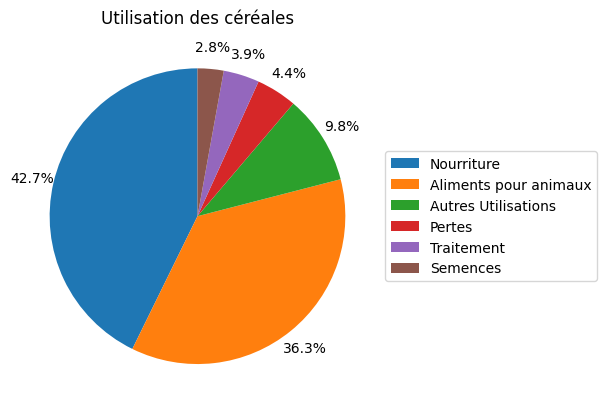

In [123]:
#Graphique sur l'utilisation des céréales
utilisation_cereale = (dispo_zone_cereale[['Aliments pour animaux','Autres Utilisations','Nourriture','Pertes','Traitement','Semences']].sum().sort_values(ascending=False))
plt.pie(utilisation_cereale.values, autopct = '%.1f%%', pctdistance= 1.15, startangle=90)
plt.title ('Utilisation des céréales')
plt.legend(utilisation_cereale.index, loc = 7, bbox_to_anchor = (1.60, 0.5))
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [124]:
#Création de la colonne proportion par pays
#dispo_zone_cereale = pd.merge((population_2017), (liste_cereale), on='Zone', how='left')
personne_sous_alimentee=pd.merge((population_2017), (sous_nutrition_2017), on='Zone', how='left')
personne_sous_alimentee['proportion'] = (personne_sous_alimentee['sous_nutrition'] / personne_sous_alimentee['Population']).round(2)*100
print(personne_sous_alimentee, "%")

                                       Zone  Année_x  Population    Année_y  \
0                               Afghanistan     2017  36296113.0  2016-2018   
1                            Afrique du Sud     2017  57009756.0  2016-2018   
2                                   Albanie     2017   2884169.0  2016-2018   
3                                   Algérie     2017  41389189.0  2016-2018   
4                                 Allemagne     2017  82658409.0  2016-2018   
..                                      ...      ...         ...        ...   
231  Venezuela (République bolivarienne du)     2017  29402484.0  2016-2018   
232                                Viet Nam     2017  94600648.0  2016-2018   
233                                   Yémen     2017  27834819.0  2016-2018   
234                                  Zambie     2017  16853599.0  2016-2018   
235                                Zimbabwe     2017  14236595.0  2016-2018   

     sous_nutrition   debut     fin  annee_intermed

In [125]:
#affichage après trie des 10 pires pays
top10=personne_sous_alimentee.sort_values(by='proportion', ascending=False).head(10)
print(top10)

                                           Zone  Année_x  Population  \
87                                        Haïti     2017  10982366.0   
181  République populaire démocratique de Corée     2017  25429825.0   
128                                  Madagascar     2017  25570512.0   
119                                     Lesotho     2017   2091534.0   
216                                       Tchad     2017  15016753.0   
122                                     Libéria     2017   4702226.0   
186                                      Rwanda     2017  11980961.0   
145                                  Mozambique     2017  28649018.0   
219                                 Timor-Leste     2017   1243258.0   
0                                   Afghanistan     2017  36296113.0   

       Année_y  sous_nutrition   debut     fin  annee_intermediaire  \
87   2016-2018       5300000.0  2016.0  2018.0               2017.0   
181  2016-2018      12000000.0  2016.0  2018.0               2017

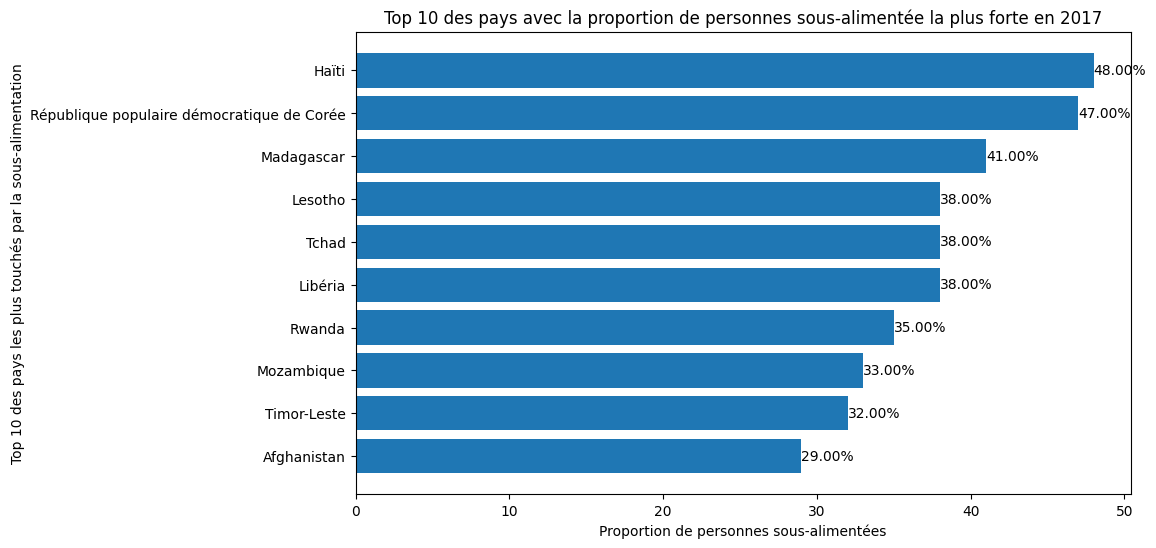

In [126]:
#Graphique en barre des 10 pire pays
top10_graph = personne_sous_alimentee.sort_values(by='proportion', ascending=False).head(10)
plt.figure(figsize=(10, 6))
bars = plt.barh(top10_graph['Zone'], top10_graph['proportion'])
plt.xlabel('Proportion de personnes sous-alimentées')
plt.ylabel('Top 10 des pays les plus touchés par la sous-alimentation')
plt.title('Top 10 des pays avec la proportion de personnes sous-alimentée la plus forte en 2017')
plt.gca().invert_yaxis()
for barh in bars :
  width = barh.get_width()
  plt.text(width, barh.get_y() + barh.get_height()/2, f'{width:.2f}%', ha='left', va='center')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [127]:
#calcul du total de l'aide alimentaire par pays
aide_total=aide_alimentaire.groupby('Zone')['Valeur'].sum().reset_index()
print(aide_total)

           Zone      Valeur
0   Afghanistan   185452000
1       Algérie    81114000
2        Angola     5014000
3    Bangladesh   348188000
4       Bhoutan     2666000
..          ...         ...
71       Zambie     3026000
72     Zimbabwe    62570000
73       Égypte     1122000
74     Équateur     1362000
75     Éthiopie  1381294000

[76 rows x 2 columns]


In [128]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
top10_aide=aide_total.sort_values(by='Valeur', ascending=False).head(10)
print(top10_aide)

                                Zone      Valeur
50         République arabe syrienne  1858943000
75                          Éthiopie  1381294000
70                             Yémen  1206484000
61                     Soudan du Sud   695248000
60                            Soudan   669784000
30                             Kenya   552836000
3                         Bangladesh   348188000
59                           Somalie   292678000
53  République démocratique du Congo   288502000
43                             Niger   276344000


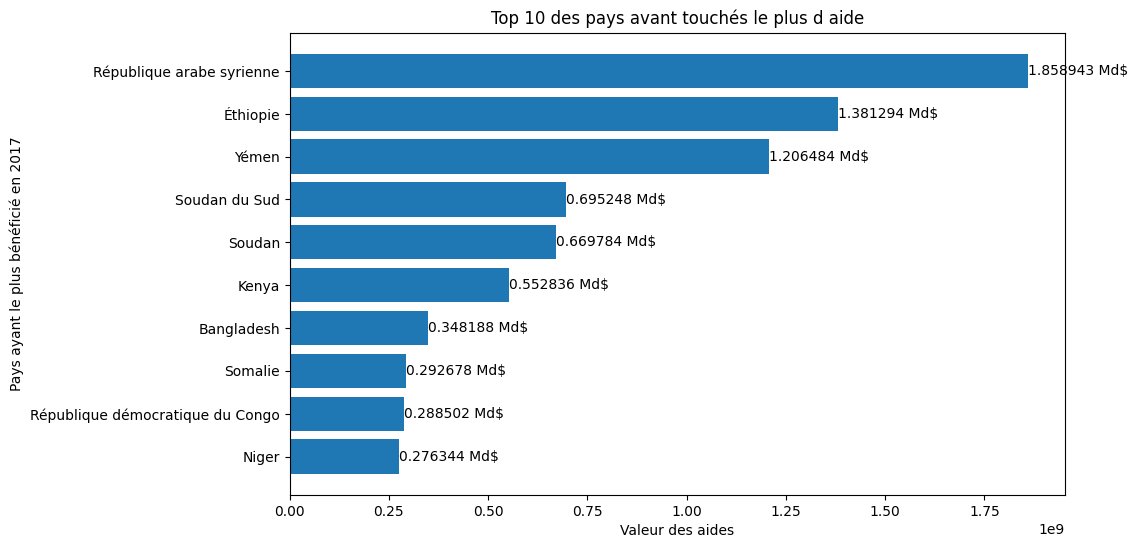

In [129]:
#Graphique en barre des 10 ayant bébénficié du plus d'aide
top10_benef = top10_aide.sort_values(by='Valeur', ascending=False).head(10)
plt.figure(figsize=(10, 6))
bars = plt.barh(top10_benef['Zone'], top10_benef['Valeur'])
plt.xlabel('Valeur des aides')
plt.ylabel('Pays ayant le plus bénéficié en 2017')
plt.title('Top 10 des pays avant touchés le plus d aide')
plt.gca().invert_yaxis()
for barh in bars :
  width = barh.get_width()
  plt.text(width, barh.get_y() + barh.get_height()/2, f'{width/1000000000} Md$', ha='left', va='center')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [130]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année
aide_zone_annee = aide_alimentaire.groupby(['Zone', 'Année'])['Valeur'].sum().reset_index()
print(aide_zone_annee)

            Zone  Année     Valeur
0    Afghanistan   2013  128238000
1    Afghanistan   2014   57214000
2        Algérie   2013   35234000
3        Algérie   2014   18980000
4        Algérie   2015   17424000
..           ...    ...        ...
223       Égypte   2013    1122000
224     Équateur   2013    1362000
225     Éthiopie   2013  591404000
226     Éthiopie   2014  586624000
227     Éthiopie   2015  203266000

[228 rows x 3 columns]


In [131]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
top5_pays = aide_zone_annee.groupby('Zone')['Valeur'].sum().nlargest(5).index.tolist()
print(top5_pays)


['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']


In [132]:
#On filtre sur le dataframe avec notre liste
aide_top5 = aide_zone_annee[aide_zone_annee['Zone'].isin(top5_pays)]
print(aide_top5)

                          Zone  Année     Valeur
157  République arabe syrienne   2013  563566000
158  République arabe syrienne   2014  651870000
159  République arabe syrienne   2015  524949000
160  République arabe syrienne   2016  118558000
189                     Soudan   2013  330230000
190                     Soudan   2014  321904000
191                     Soudan   2015   17650000
192              Soudan du Sud   2013  196330000
193              Soudan du Sud   2014  450610000
194              Soudan du Sud   2015   48308000
214                      Yémen   2013  264764000
215                      Yémen   2014  103840000
216                      Yémen   2015  372306000
217                      Yémen   2016  465574000
225                   Éthiopie   2013  591404000
226                   Éthiopie   2014  586624000
227                   Éthiopie   2015  203266000


In [133]:
# Affichage des pays avec l'aide alimentaire par année
aide_top5_affichage = aide_top5.pivot_table(index='Zone', columns='Année', values='Valeur',aggfunc='sum')
print(aide_top5_affichage)


Année                             2013         2014         2015         2016
Zone                                                                         
République arabe syrienne  563566000.0  651870000.0  524949000.0  118558000.0
Soudan                     330230000.0  321904000.0   17650000.0          NaN
Soudan du Sud              196330000.0  450610000.0   48308000.0          NaN
Yémen                      264764000.0  103840000.0  372306000.0  465574000.0
Éthiopie                   591404000.0  586624000.0  203266000.0          NaN


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [134]:
#Calcul de la disponibilité en kcal par personne par jour par pays
pays_dispo_kcal = dispo_alimentaire.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index()
print(pays_dispo_kcal)

                      Zone  Disponibilité alimentaire (Kcal/personne/jour)
0              Afghanistan                                          2087.0
1           Afrique du Sud                                          3020.0
2                  Albanie                                          3188.0
3                  Algérie                                          3293.0
4                Allemagne                                          3503.0
..                     ...                                             ...
169    Émirats arabes unis                                          3275.0
170               Équateur                                          2346.0
171  États-Unis d'Amérique                                          3682.0
172               Éthiopie                                          2129.0
173           Îles Salomon                                          2383.0

[174 rows x 2 columns]


In [135]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
flop10_dispo=pays_dispo_kcal.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)', ascending=True).head(10)
print(flop10_dispo)


                                           Zone  \
128                   République centrafricaine   
166                                      Zambie   
91                                   Madagascar   
0                                   Afghanistan   
65                                        Haïti   
133  République populaire démocratique de Corée   
151                                       Tchad   
167                                    Zimbabwe   
114                                     Ouganda   
172                                    Éthiopie   

     Disponibilité alimentaire (Kcal/personne/jour)  
128                                          1879.0  
166                                          1924.0  
91                                           2056.0  
0                                            2087.0  
65                                           2089.0  
133                                          2093.0  
151                                          2109.0  
167   

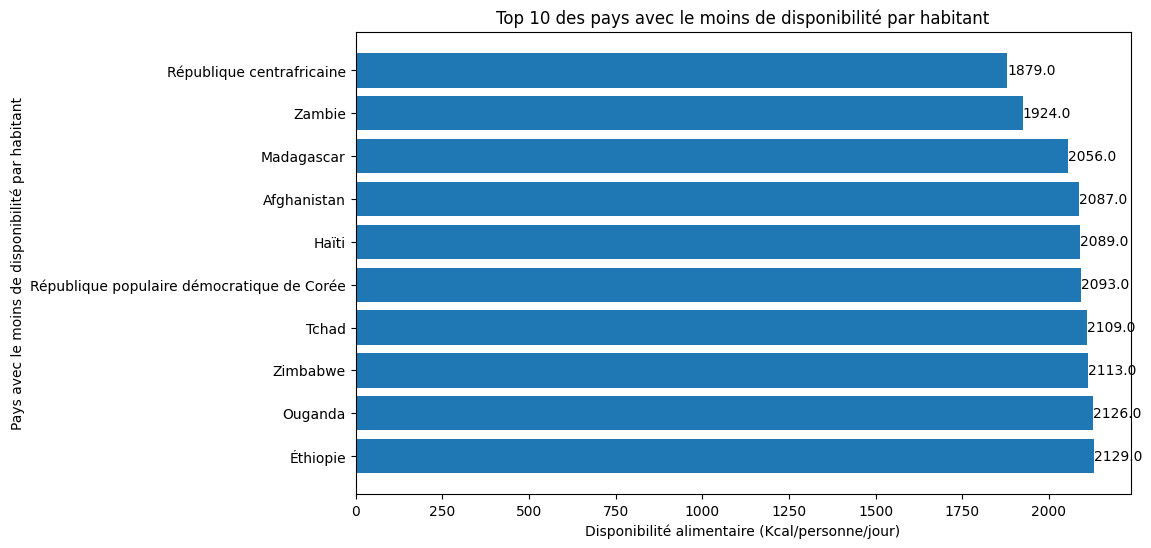

In [136]:
#Graphique des pays avec le moins de dispo alimentaire
flop10_dispo_graph = flop10_dispo.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)', ascending=False).head(10)
plt.figure(figsize=(10, 6))
bars = plt.barh(flop10_dispo['Zone'], flop10_dispo['Disponibilité alimentaire (Kcal/personne/jour)'])
plt.xlabel('Disponibilité alimentaire (Kcal/personne/jour)')
plt.ylabel('Pays avec le moins de disponibilité par habitant')
plt.title('Top 10 des pays avec le moins de disponibilité par habitant')
plt.gca().invert_yaxis()
for barh in bars :
  width = barh.get_width()
  plt.text(width, barh.get_y() + barh.get_height()/2, f'{width}', ha='left', va='center')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [137]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
top10_dispo = pays_dispo_kcal.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)', ascending=False).head(10)
print(top10_dispo)

                      Zone  Disponibilité alimentaire (Kcal/personne/jour)
11                Autriche                                          3770.0
16                Belgique                                          3737.0
159                Turquie                                          3708.0
171  États-Unis d'Amérique                                          3682.0
74                  Israël                                          3610.0
72                 Irlande                                          3602.0
75                  Italie                                          3578.0
89              Luxembourg                                          3540.0
168                 Égypte                                          3518.0
4                Allemagne                                          3503.0


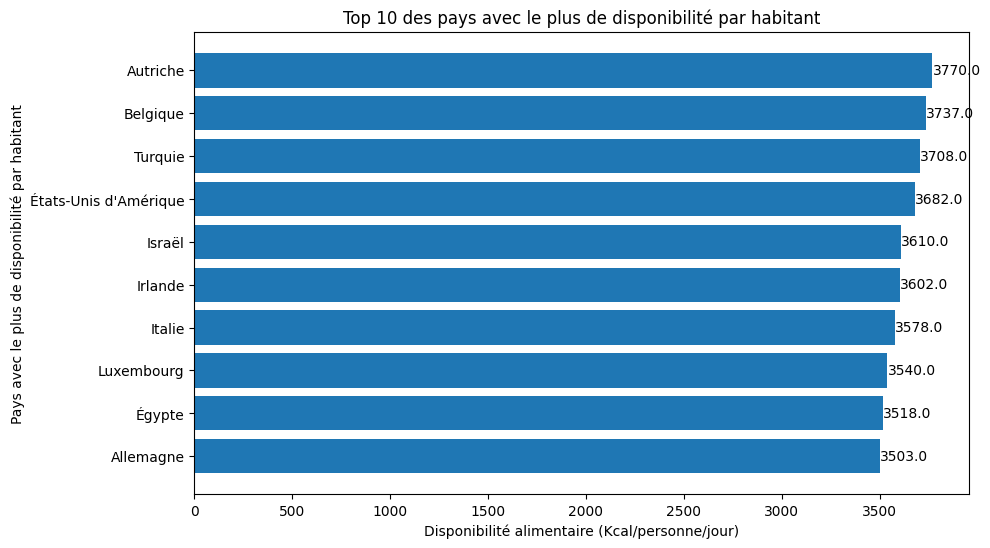

In [138]:
#Pays avec le plus de disponibilité par habitant
top10_dispo_graph = top10_dispo.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)', ascending=False).head(10)
plt.figure(figsize=(10, 6))
bars = plt.barh(top10_dispo['Zone'], top10_dispo['Disponibilité alimentaire (Kcal/personne/jour)'])
plt.xlabel('Disponibilité alimentaire (Kcal/personne/jour)')
plt.ylabel('Pays avec le plus de disponibilité par habitant')
plt.title('Top 10 des pays avec le plus de disponibilité par habitant')
plt.gca().invert_yaxis()
for barh in bars :
  width = barh.get_width()
  plt.text(width, barh.get_y() + barh.get_height()/2, f'{width}', ha='left', va='center')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [139]:
#création d'un dataframe avec uniquement la Thaïlande
thailande = personne_sous_alimentee[personne_sous_alimentee['Zone'] == 'Thaïlande']
print(thailande)

          Zone  Année_x  Population    Année_y  sous_nutrition   debut  \
218  Thaïlande     2017  69209810.0  2016-2018       6200000.0  2016.0   

        fin  annee_intermediaire  proportion  
218  2018.0               2017.0         9.0  


In [140]:
#Calcul de la sous nutrition en Thaïlande
#personne_sous_alimentee['proportion'] = (personne_sous_alimentee['sous_nutrition'] / personne_sous_alimentee['Population']).round(2)*100
thai_sous_nutrition = thailande['proportion'].iloc[0]
print(f"La proportion de sous-nutrition en Thailande est de : {thai_sous_nutrition:.2f}%")

La proportion de sous-nutrition en Thailande est de : 9.00%


In [141]:
# On calcule la proportion exportée en fonction de la proportion
manioc_thai=dispo_alimentaire[(dispo_alimentaire['Zone'] == 'Thaïlande') & (dispo_alimentaire['Produit'] == 'Manioc')]
prop_export_manioc = manioc_thai['Exportations - Quantité'].iloc[0]*100/manioc_thai['Production'].iloc[0]
print(f"La proportion exportée de manioc en Thaïlande est de : {prop_export_manioc:.2f}%")

La proportion exportée de manioc en Thaïlande est de : 83.41%


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

L'évolution de la sous-nutrition et de l'aide alimentaire depuis 2013

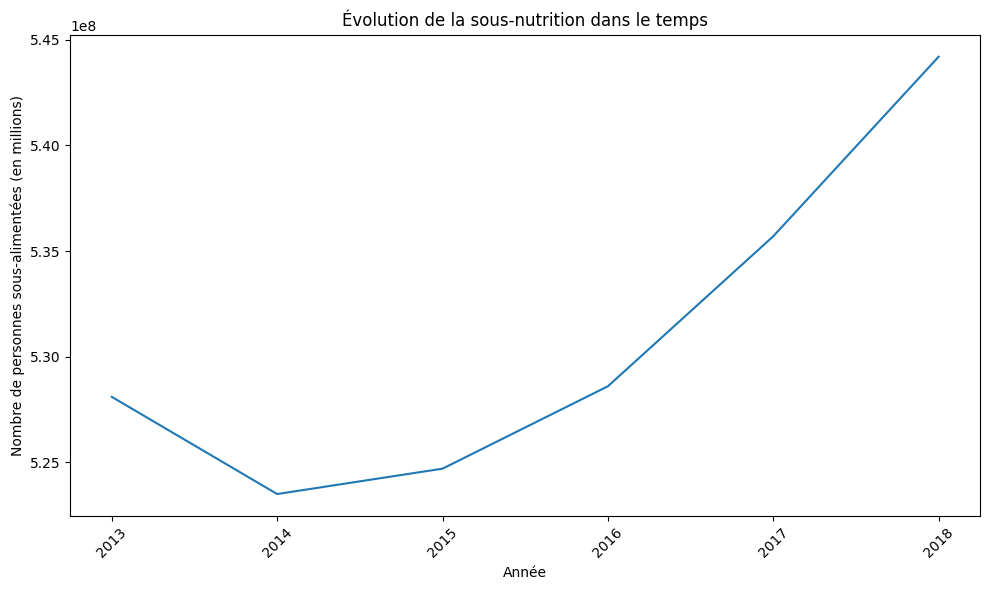

In [142]:
import matplotlib.pyplot as plt

# extraire les années de sous-nutrition
sous_nutrition[['debut','fin']]=sous_nutrition['Année'].str.split('-',expand=True).astype(int)
  # calculer l'année intermédiaire
sous_nutrition['annee_intermediaire']=((sous_nutrition['debut']+sous_nutrition['fin'])/2).astype(int)

# grouper par année et faire la somme
sous_nutrition_evolution = sous_nutrition.groupby('annee_intermediaire')['sous_nutrition'].sum().reset_index()

# affichage de la courbe
plt.figure(figsize=(10, 6))
plt.plot(sous_nutrition_evolution['annee_intermediaire'], sous_nutrition_evolution['sous_nutrition'])
plt.xlabel('Année')
plt.ylabel('Nombre de personnes sous-alimentées (en millions)')
plt.title('Évolution de la sous-nutrition dans le temps')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

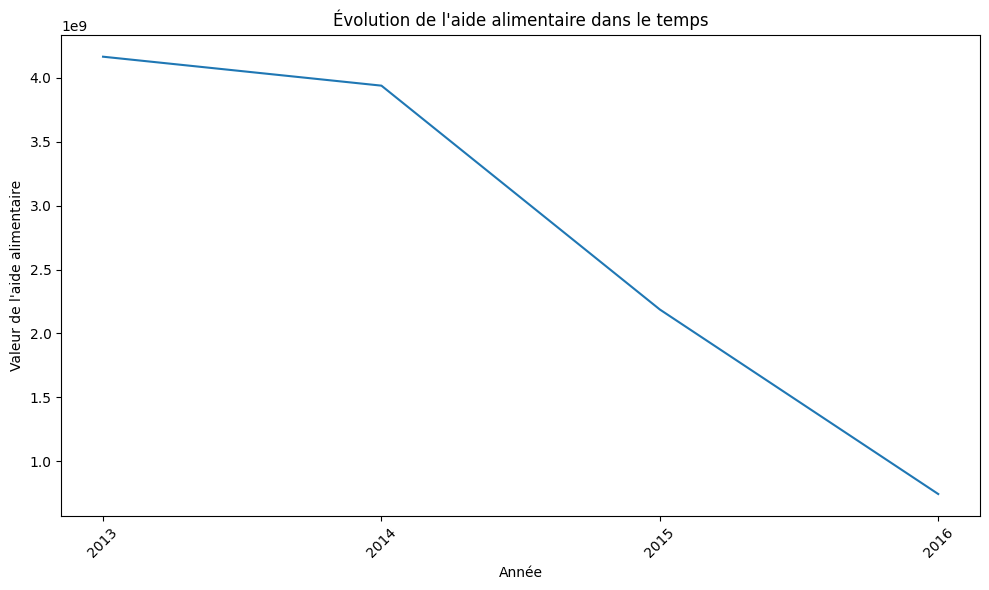

In [143]:
import matplotlib.pyplot as plt

# Groupé par année et faire la somme
aide_evolution = aide_alimentaire.groupby('Année')['Valeur'].sum().reset_index()

# affichage de la courbe
plt.figure(figsize=(10, 6))
plt.plot(aide_evolution['Année'], aide_evolution['Valeur'])
plt.xlabel('Année')
plt.ylabel('Valeur de l\'aide alimentaire')
plt.title('Évolution de l\'aide alimentaire dans le temps')
plt.xticks(aide_evolution['Année'], rotation=45)
plt.tight_layout()
plt.show()

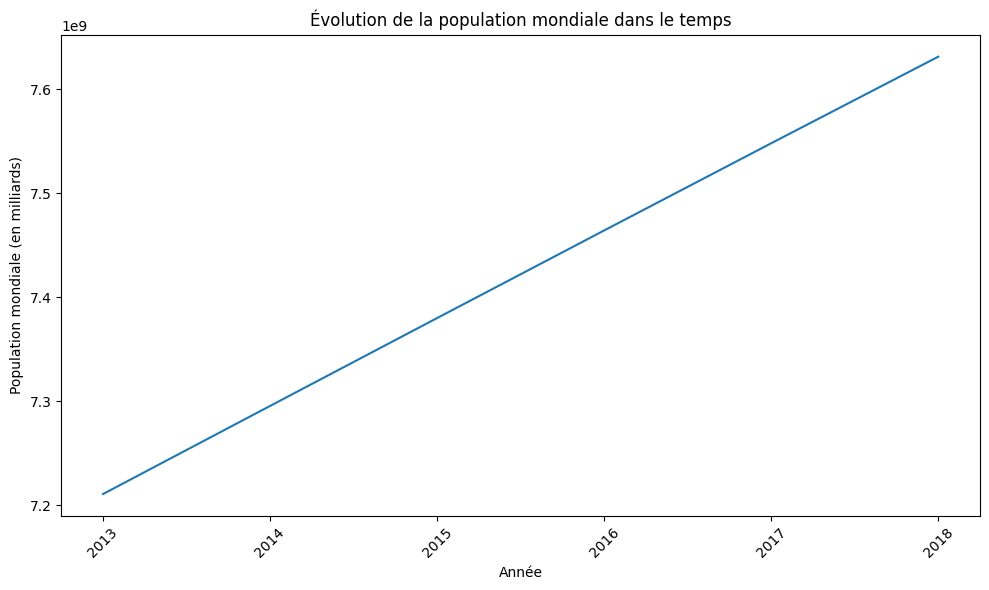

In [144]:
import matplotlib.pyplot as plt

# grouper par année et faire la somme
population_evolution = population.groupby('Année')['Population'].sum().reset_index()

# affichage de la courbe
plt.figure(figsize=(10, 6))
plt.plot(population_evolution['Année'], population_evolution['Population'])
plt.xlabel('Année')
plt.ylabel('Population mondiale (en milliards)')
plt.title('Évolution de la population mondiale dans le temps')
plt.xticks(population_evolution['Année'], rotation=45)
plt.tight_layout()
plt.show()

On constate que la population ne cesse de croitre et que la sous-nutrition s'accélère dans le temps. Dans le temps, l'aide alimentaire, elle, baisse.